# Profile, validate and model: NYC HVFHV trips, June 2026

This notebook is the investigation behind the pipeline. It walks the class method on the real data:
retrieve, prove completeness, profile, turn what profiling shows into rules, model the workflow, and
compute the metrics. Every rule and threshold in `pipeline/` came from a finding here.

It reuses the pipeline's own functions (`pipeline.model`, `pipeline.validate`) instead of copying their
logic, so what you see here is what the monthly run does.

**Prerequisite:** run `python run_pipeline.py --from 2026-05 --to 2026-07` once. It downloads and
verifies the raw files this notebook reads.

In [1]:
import json
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from pipeline import model, validate
from pipeline.config import load_config
from pipeline.runner import month_bounds

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
cfg = load_config()
MONTH = "2026-06"
RAW = ROOT / "data" / "raw"
trip_path = RAW / "tlc" / "fhvhv" / f"month={MONTH}" / f"fhvhv_tripdata_{MONTH}.parquet"
zone_path = RAW / "reference" / "taxi_zone_lookup.csv"

con = model.connect()
model.register_sources(con, trip_path, zone_path, cfg)
q = lambda sql: con.execute(sql).df()

## 1. Retrieval: how do we know we got everything?

Two retrieval modes: files over HTTPS (trip Parquet, zone lookup CSV) and the NYC Open Data REST API
(TLC's own published aggregates). Each raw input is kept unchanged under `data/raw/`, with a manifest
recording the evidence below.

In [2]:
rows = []
for m in ["2026-05", "2026-06", "2026-07"]:
    man = json.loads((RAW / "tlc" / "fhvhv" / f"month={m}" / "_manifest.json").read_text())
    rows.append({"month": m, "remote Content-Length": man["remote_content_length"],
                 "bytes on disk": man["bytes_on_disk"], "bytes match": man["bytes_match"],
                 "Parquet footer rows": man["parquet_footer_rows"], "sha256": man["sha256"][:16] + "..."})
pd.DataFrame(rows)

,month,remote Content-Length,bytes on disk,bytes match,Parquet footer rows,sha256
0,2026-05,537576484,537576484,True,22125744,e2b633a5be2280da...
1,2026-06,506800012,506800012,True,20775868,300f8dccfae90253...
2,2026-07,511176663,511176663,True,20921249,8da280d9d23813aa...


A byte-perfect download only proves we received the file TLC published. Section 7 checks whether the
file holds every trip TLC itself reports. (It does not for June.)

The first manual download of July, done with a plain `curl` before the pipeline existed, stopped at
76 MB of 511 MB and still exited 0. The pipeline noticed the size mismatch and downloaded the file again.
That is why the byte check exists.

## 2. Profile: what is in the file

In [3]:
schema = q("DESCRIBE source_trips")[["column_name", "column_type"]]
nulls = q("SELECT " + ", ".join(f"round(100 * avg(({c} IS NULL)::INT), 3) AS \"{c}\"" for c in schema.column_name)
          + " FROM source_trips").T.rename(columns={0: "null %"})
schema.set_index("column_name").join(nulls)

,column_type,null %
column_name,,
hvfhs_license_num,VARCHAR,0.000
dispatching_base_num,VARCHAR,0.000
originating_base_num,VARCHAR,26.453
request_datetime,TIMESTAMP,0.000
on_scene_datetime,TIMESTAMP,0.000
pickup_datetime,TIMESTAMP,0.000
dropoff_datetime,TIMESTAMP,0.000
PULocationID,INTEGER,0.000
DOLocationID,INTEGER,0.000


In [4]:
q('''
SELECT hvfhs_license_num AS license, count(*) AS trips,
       round(100 * count(*) / sum(count(*)) OVER (), 1) AS share_pct,
       count(DISTINCT dispatching_base_num) AS bases
FROM source_trips GROUP BY 1 ORDER BY 1
''')

,license,trips,share_pct,bases
0,HV0003,15257740,73.4,1
1,HV0005,5518128,26.6,1


**Finding: DuckDB invents a column if you let it.** The raw file sits in a folder named
`month=2026-06`. With default settings, `read_parquet` treats that as a Hive partition and adds a
`month` column that is not in the source. `pipeline.model.register_sources` turns
`hive_partitioning` off, and a test guards it.

## 3. Timestamp semantics: what does each workflow event mean?

The workflow is `request -> driver on scene -> pickup -> dropoff`. The TLC data dictionary (March 2025)
says `on_scene_datetime` is recorded for **accessible vehicles only**. The data disagrees.

In [5]:
q('''
SELECT hvfhs_license_num AS license,
       round(100 * avg((on_scene_datetime IS NULL)::INT), 2)                 AS on_scene_null_pct,
       round(100 * avg((wav_match_flag = 'Y')::INT), 2)                      AS wav_vehicle_pct,
       round(100 * avg((on_scene_datetime = pickup_datetime)::INT), 2)       AS on_scene_equals_pickup_pct,
       round(100 * avg((on_scene_datetime < request_datetime)::INT), 2)      AS on_scene_before_request_pct,
       round(100 * avg((pickup_datetime < request_datetime)::INT), 2)        AS pickup_before_request_pct
FROM source_trips GROUP BY 1 ORDER BY 1
''')

,license,on_scene_null_pct,wav_vehicle_pct,on_scene_equals_pickup_pct,on_scene_before_request_pct,pickup_before_request_pct
0,HV0003,0.0,11.59,6.67,1.87,1.21
1,HV0005,0.0,6.48,0.14,1.82,1.37


- `on_scene_datetime` is filled for **every** trip from both licensees, not only accessible vehicles.
  The dictionary no longer describes the field.
- Uber stamps arrival at exactly the pickup time on 6.7% of trips; Lyft almost never does. So the
  same field is recorded differently by the two licensees. The arrival/boarding split (metric M3) is
  descriptive only, never a licensee comparison.
- About 1.3% of trips are **picked up before they were requested**. That is impossible for an
  on-demand ride. See below.

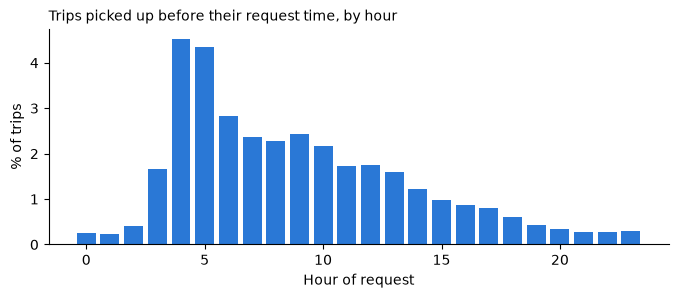

In [6]:
neg = q('''
SELECT extract(hour FROM request_datetime) AS request_hour,
       round(100 * avg((pickup_datetime < request_datetime)::INT), 2) AS pickup_before_request_pct
FROM source_trips GROUP BY 1 ORDER BY 1
''')
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.bar(neg.request_hour, neg.pickup_before_request_pct, color="#2a78d6")
ax.set_xlabel("Hour of request"); ax.set_ylabel("% of trips")
ax.set_title("Trips picked up before their request time, by hour", loc="left", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [7]:
q('''
SELECT hvfhs_license_num AS license, wav_request_flag AS wav_requested, count(*) AS trips,
       round(100 * avg((pickup_datetime < request_datetime)::INT), 2) AS pickup_before_request_pct,
       round(median(date_diff('second', request_datetime, pickup_datetime)) FILTER
             (WHERE pickup_datetime < request_datetime) / 60.0, 1) AS median_negative_wait_min
FROM source_trips GROUP BY ALL ORDER BY ALL
''')

,license,wav_requested,trips,pickup_before_request_pct,median_negative_wait_min
0,HV0003,N,15212930,1.21,-6.1
1,HV0003,Y,44810,3.38,-7.6
2,HV0005,N,5495740,1.17,-6.1
3,HV0005,Y,22388,51.72,-7.3


The negative "waits" peak at 4 to 5 AM (airport runs booked the night before) and make up **over half
of Lyft's wheelchair-accessible trips**. The most likely explanation is pre-scheduled rides whose
`request_datetime` holds the booked time rather than the moment the rider asked.

The data has no reservation flag, so this cannot be confirmed from the file. That makes it a question
for the data owner, not something to fix.

**Decision (rule R03):** quarantine these trips from every wait metric and report how many there are,
by segment. Three alternatives were rejected:
- **Clipping them to zero** would record them as perfect service and push the long-wait rate *down*.
  For Lyft WAV trips, clipping would report a long-wait rate of about 18% instead of 37%.
- **Dropping them silently** would halve the Lyft WAV denominator without anyone knowing.
- **Keeping the negative values** would put impossible numbers into medians.

## 4. Trip duration: does `trip_time` agree with the timestamps?

In [8]:
q('''
SELECT hvfhs_license_num AS license,
       quantile_cont(trip_time - date_diff('second', pickup_datetime, dropoff_datetime),
                     [0.01, 0.5, 0.9, 0.99]) AS trip_time_minus_timestamps_s,
       round(100 * avg((abs(trip_time - date_diff('second', pickup_datetime, dropoff_datetime)) > 60)::INT), 2)
           AS over_60s_apart_pct
FROM source_trips GROUP BY 1 ORDER BY 1
''')

,license,trip_time_minus_timestamps_s,over_60s_apart_pct
0,HV0003,"[-1.0, 0.0, 1.0, 1.0]",0.02
1,HV0005,"[0.0, 0.0, 65.0, 308.0]",10.48


Uber's `trip_time` matches dropoff minus pickup to the second. Lyft's is never shorter but is more than
a minute longer on about 10% of trips (up to 5 minutes at P99). The extra time is not explained by the
on-scene timestamp either.

**Decision:**
- Duration is always computed from the timestamps, which mean the same thing for both licensees.
- The mismatch is reported (R09) and does not remove trips from any metric.
- What Lyft's `trip_time` includes is a question for the owner.

## 5. Duration and location plausibility

In [9]:
q(f'''
SELECT
  count(*) FILTER (WHERE trip_miles <= 0)                                              AS zero_or_negative_miles,
  count(*) FILTER (WHERE date_diff('second', pickup_datetime, dropoff_datetime) <= 0)  AS dropoff_not_after_pickup,
  count(*) FILTER (WHERE date_diff('second', pickup_datetime, dropoff_datetime) > 4 * 3600) AS over_4_hours,
  count(*) FILTER (WHERE trip_miles / nullif(date_diff('second', pickup_datetime, dropoff_datetime) / 3600.0, 0) > 70)
                                                                                      AS over_70_mph,
  count(*) FILTER (WHERE trip_miles / nullif(date_diff('second', pickup_datetime, dropoff_datetime) / 3600.0, 0) < 1)
                                                                                      AS under_1_mph,
  count(*) FILTER (WHERE date_diff('second', request_datetime, pickup_datetime) > 3600) AS wait_over_60_min,
  count(*) FILTER (WHERE PULocationID IN (264, 265))                                   AS pickup_zone_unknown,
  count(*) FILTER (WHERE DOLocationID IN (264, 265))                                   AS dropoff_zone_unknown,
  count(*) FILTER (WHERE pickup_datetime < TIMESTAMP '{month_bounds(MONTH)[0]}'
                      OR pickup_datetime >= TIMESTAMP '{month_bounds(MONTH)[1]}')      AS pickup_outside_month
FROM source_trips
''').T.rename(columns={0: "trips"})

,trips
zero_or_negative_miles,4844
dropoff_not_after_pickup,2
over_4_hours,426
over_70_mph,586
under_1_mph,9809
wait_over_60_min,958
pickup_zone_unknown,1241
dropoff_zone_unknown,987775
pickup_outside_month,0


Profiling tells you where to look, not what to delete:
- **Under 1 mph (about 9,800 trips):** these are slow but possible (a short hop stuck in traffic). They
  are **not** a rule.
- **Implausible trips (zero miles, over 4 hours, over 70 mph):** held out of the KPI (R06), because such
  a record may not describe a real passenger trip.
- **Dropoff zone unknown (about 1M trips):** almost all are zone 265, "Outside of NYC". These are real
  trips to New Jersey and beyond, and the KPI only uses the pickup zone, so they are kept.
- **Pickup zone unknown (about 1,200 trips):** kept citywide and left out of borough views (R07).

## 6. Workflow stages: where the wait sits

In [10]:
q('''
SELECT hvfhs_license_num AS license,
       quantile_cont(date_diff('second', request_datetime, pickup_datetime) / 60.0, [0.5, 0.9, 0.99])
           FILTER (WHERE pickup_datetime >= request_datetime) AS wait_min_p50_p90_p99,
       quantile_cont(date_diff('second', request_datetime, on_scene_datetime) / 60.0, [0.5, 0.9])
           FILTER (WHERE on_scene_datetime BETWEEN request_datetime AND pickup_datetime) AS arrival_min_p50_p90,
       quantile_cont(date_diff('second', on_scene_datetime, pickup_datetime) / 60.0, [0.5, 0.9])
           FILTER (WHERE on_scene_datetime BETWEEN request_datetime AND pickup_datetime) AS boarding_min_p50_p90
FROM source_trips GROUP BY 1 ORDER BY 1
''')

,license,wait_min_p50_p90_p99,arrival_min_p50_p90,boarding_min_p50_p90
0,HV0003,"[4.733333333333333, 11.333333333333334, 20.35]","[3.85, 10.45]","[0.6333333333333333, 2.0]"
1,HV0005,"[4.816666666666666, 9.25, 17.033333333333335]","[3.6166666666666667, 7.833333333333333]","[0.7166666666666667, 2.9833333333333334]"


Most of the wait is the driver getting to the rider (median about 3.8 of 4.8 minutes). Boarding (on
scene to pickup) is under a minute at the median.

The KPI therefore measures request to pickup: that is what the rider experiences, and both licensees
record it the same way.

## 7. Completeness beyond the download: daily volume and TLC's own totals

An internal check first: each licensee's daily trips against its usual volume for that weekday.

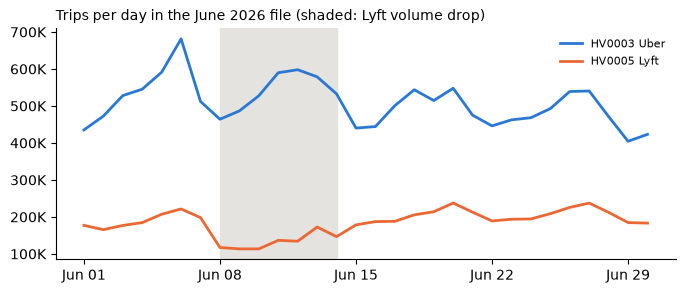

{'check': 'D06.daily_volume_dips',
 'status': 'WARN',
 'detail': '6 licensee-days below 75% of their weekday median; estimated shortfall 393105 trips',
 'dips': [{'license': 'HV0005',
   'day': '2026-06-08',
   'trips': 117202,
   'weekday_median': 178485,
   'ratio': 0.657},
  {'license': 'HV0005',
   'day': '2026-06-09',
   'trips': 113548,
   'weekday_median': 183242,
   'ratio': 0.62},
  {'license': 'HV0005',
   'day': '2026-06-10',
   'trips': 113530,
   'weekday_median': 182484,
   'ratio': 0.622},
  {'license': 'HV0005',
   'day': '2026-06-11',
   'trips': 136629,
   'weekday_median': 195072,
   'ratio': 0.7},
  {'license': 'HV0005',
   'day': '2026-06-12',
   'trips': 134260,
   'weekday_median': 210554,
   'ratio': 0.638},
  {'license': 'HV0005',
   'day': '2026-06-14',
   'trips': 146701,
   'weekday_median': 205138,
   'ratio': 0.715}],
 'estimated_shortfall': 393105}

In [11]:
daily = q('''
SELECT pickup_datetime::DATE AS day, hvfhs_license_num AS license, count(*) AS trips
FROM source_trips GROUP BY ALL ORDER BY ALL
''').pivot(index="day", columns="license", values="trips")
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(daily.index, daily["HV0003"], color="#2a78d6", lw=2, label="HV0003 Uber")
ax.plot(daily.index, daily["HV0005"], color="#eb6834", lw=2, label="HV0005 Lyft")
ax.axvspan(pd.Timestamp("2026-06-08"), pd.Timestamp("2026-06-14"), color="#e4e3df", zorder=0)
ax.set_title("Trips per day in the June 2026 file (shaded: Lyft volume drop)", loc="left", fontsize=10)
import matplotlib.dates as mdates, matplotlib.ticker as mticker
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1000:.0f}K"))
ax.legend(frameon=False, fontsize=8); ax.spines[["top", "right"]].set_visible(False)
plt.show()
validate.check_daily_volume(con, *month_bounds(MONTH), cfg["validation"]["daily_dip_ratio"])

In [12]:
recon = json.loads((ROOT / "outputs" / f"month={MONTH}" / "reconciliation.json").read_text())
pd.DataFrame(recon["checks"])[["check", "status", "detail"]]

,check,status,detail
0,C01.pickups_vs_tlc_zone_report,FAIL,file 20775868 vs TLC published 21231358 pickup...
1,C02.trips_vs_tlc_base_report,UNKNOWN,TLC has not published the 2026-06 base report ...


In [13]:
zones = pd.read_csv(ROOT / "outputs" / f"month={MONTH}" / "reconciliation_zone.csv")
zones["delta_pct"] = 100 * zones.delta / zones.tlc_trips
zones[zones.tlc_trips >= 1000].delta_pct.describe().round(2)

count    255.00
mean      -2.16
std        0.32
min       -5.70
25%       -2.26
50%       -2.13
75%       -2.01
max       -1.60
Name: delta_pct, dtype: float64

Both checks point to the same gap.
- **Size:** TLC's published June total is 455,490 pickups (2.1%) higher than the file.
- **Where it is not:** the gap is spread evenly across zones (median -2.1%, spread 0.3 points), so it is
  not geographic.
- **Where it is:** Lyft's daily volume drops by about a third for June 8 to 14 while Uber's is normal.
  The internal check estimates a shortfall of about 393K trips, close to the external gap.

The most likely reading is that Lyft records for that week are missing from the published file. May
reconciles to the exact trip per licensee. July reconciles to within 0.01%.

## 8. Model: from source rows to the workflow table

The source is organised by how TLC publishes it (one flat row per trip, stamped by licensees). The
model reorganises it around the rider's workflow: `fact_trip` (silver) holds stage durations, zone and
borough, rider requests and every validation flag, with **no row dropped**.

Aggregates are built before any join. Joining 20M trips to TLC's zone report row by row would be
meaningless; both sides are first reduced to one row per zone.

In [14]:
silver = ROOT / "data" / "silver" / f"month={MONTH}" / "fact_trip.parquet"
con.execute(f"CREATE OR REPLACE VIEW fact_trip AS SELECT * FROM read_parquet('{silver.as_posix()}')")
print("source rows:", con.execute("SELECT count(*) FROM source_trips").fetchone()[0],
      "| silver rows:", con.execute("SELECT count(*) FROM fact_trip").fetchone()[0])
q("SELECT * FROM fact_trip LIMIT 3").T

source rows: 20775868 | silver rows: 20775868


,0,1,2
license,HV0005,HV0005,HV0005
brand,Lyft,Lyft,Lyft
dispatching_base,B03406,B03406,B03406
requested_at,2026-06-06 20:20:40,2026-06-06 20:28:00,2026-06-06 20:42:55
on_scene_at,2026-06-06 20:24:46,2026-06-06 20:30:57,2026-06-06 20:47:04
picked_up_at,2026-06-06 20:24:55,2026-06-06 20:32:24,2026-06-06 20:48:34
dropped_off_at,2026-06-06 20:30:20,2026-06-06 20:39:09,2026-06-06 21:11:30
wait_s,255,264,339
arrival_s,246,177,249
boarding_s,9,87,90


In [15]:
q('''
SELECT count(*) AS trips,
       count(*) FILTER (WHERE in_kpi) AS in_kpi,
       count(*) FILTER (WHERE in_borough_kpi) AS in_borough_kpi,
       count(*) FILTER (WHERE in_stage_split) AS in_stage_split
FROM fact_trip
''')

,trips,in_kpi,in_borough_kpi,in_stage_split
0,20775868,20508401,20507194,20384193


## 9. Metrics (the same SQL the pipeline runs)

In [16]:
from pipeline import metrics
b = metrics.borough_metrics(con, cfg, MONTH)
b[b.licensee == "All"][["pickup_borough", "trips_measured", "long_wait_rate", "long_wait_rate_5min",
                         "long_wait_rate_15min", "median_wait_min", "p90_wait_min",
                         "median_arrival_min", "median_boarding_min"]]

,pickup_borough,trips_measured,long_wait_rate,long_wait_rate_5min,long_wait_rate_15min,median_wait_min,p90_wait_min,median_arrival_min,median_boarding_min
0,Bronx,2760135,0.1400,0.5190,0.0417,5.15,11.37,4.10,0.72
1,Brooklyn,5652112,0.1230,0.4788,0.0367,4.85,10.83,3.87,0.65
2,Citywide,20508401,0.1204,0.4674,0.0358,4.77,10.75,3.78,0.65
3,Manhattan,7044507,0.0978,0.4255,0.0277,4.47,9.93,3.47,0.63
4,Queens,4711580,0.1359,0.4794,0.0417,4.85,11.28,3.88,0.65
5,Staten Island,338860,0.1703,0.5601,0.0584,5.47,12.45,4.60,0.53
6,Unknown / outside NYC,1207,0.3935,0.8351,0.1632,8.57,17.52,7.63,0.55


In [17]:
metrics.wav_metrics(con, cfg, MONTH)

,month,licensee,rider_request,trips_total,trips_measured,measured_share,pickup_before_request_share,long_wait_rate,median_wait_min,wav_vehicle_share
0,2026-06,All,Standard,20708670,20454348,0.9877,0.0120,0.1199,4.75,0.0994
1,2026-06,All,WAV requested,67198,54053,0.8044,0.1948,0.3202,8.12,1.0000
2,2026-06,Lyft,Standard,5495740,5430569,0.9881,0.0117,0.0761,4.80,0.0610
3,2026-06,Lyft,WAV requested,22388,10800,0.4824,0.5172,0.3733,8.53,1.0000
4,2026-06,Uber,Standard,15212930,15023779,0.9876,0.0121,0.1357,4.73,0.1133
5,2026-06,Uber,WAV requested,44810,43253,0.9653,0.0338,0.3069,8.03,1.0000


## 10. What this investigation changed

| Finding | Where it went |
|---|---|
| on_scene filled for all trips, recorded differently per licensee | M3 descriptive only; R08 for out-of-order values; owner question |
| 1.3% picked up before request, over half of Lyft WAV trips | R03 quarantine, never clip; M4 shows the unmeasurable share |
| Lyft `trip_time` longer than its timestamps | Duration from timestamps; R09 report only |
| Waits over 60 min are rare (under 1,000 trips) | R04 cap, counted |
| Dropoff zone 265 is out-of-city trips, not errors | Not a rule; pickup zone drives the KPI |
| Folder name read as a column | `hive_partitioning = false`, tested |
| File 2.1% short of TLC's own count, Lyft June 8 to 14 | D06 internal check + C01 reconciliation, June on HOLD with KPI bounds |
| Truncated manual download exited 0 | Byte and checksum verification on every download |